In [1]:
print("Hello")


Hello


In [2]:
print("Hello")

Hello


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("marketing_data.csv")

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   2240 non-null   int64
 1   Year_Birth           2240 non-null   int64
 2   Education            2240 non-null   str  
 3   Marital_Status       2240 non-null   str  
 4    Income              2216 non-null   str  
 5   Kidhome              2240 non-null   int64
 6   Teenhome             2240 non-null   int64
 7   Dt_Customer          2240 non-null   str  
 8   Recency              2240 non-null   int64
 9   MntWines             2240 non-null   int64
 10  MntFruits            2240 non-null   int64
 11  MntMeatProducts      2240 non-null   int64
 12  MntFishProducts      2240 non-null   int64
 13  MntSweetProducts     2240 non-null   int64
 14  MntGoldProds         2240 non-null   int64
 15  NumDealsPurchases    2240 non-null   int64
 16  NumWebPurchases      2240 non-null 

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [9]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

C:\Users\abhir\AppData\Local\Temp\ipykernel_29236\177162232.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])


In [10]:
df['Education'].unique()

<StringArray>
['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
Length: 5, dtype: str

In [11]:
df['Marital_Status'].unique()

<StringArray>
['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO', 'Alone',
 'Absurd']
Length: 8, dtype: str

In [12]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Together': 'Married',
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Alone': 'Single'
})

In [16]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

In [17]:
df.columns = df.columns.str.strip()

In [19]:
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

In [20]:
df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.mean())
)

In [21]:
df.isnull().sum()

ID                        0
Year_Birth                0
Education                 0
Marital_Status            0
Income                 2240
Kidhome                   0
Teenhome                  0
Dt_Customer               0
Recency                   0
MntWines                  0
MntFruits                 0
MntMeatProducts           0
MntFishProducts           0
MntSweetProducts          0
MntGoldProds              0
NumDealsPurchases         0
NumWebPurchases           0
NumCatalogPurchases       0
NumStorePurchases         0
NumWebVisitsMonth         0
AcceptedCmp3              0
AcceptedCmp4              0
AcceptedCmp5              0
AcceptedCmp1              0
AcceptedCmp2              0
Response                  0
Complain                  0
Country                   0
dtype: int64

In [22]:
df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')



In [23]:
df['Income'].head()


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Income, dtype: float64

In [24]:
df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.mean())
)

In [25]:
df.isnull().sum()

ID                        0
Year_Birth                0
Education                 0
Marital_Status            0
Income                 2240
Kidhome                   0
Teenhome                  0
Dt_Customer               0
Recency                   0
MntWines                  0
MntFruits                 0
MntMeatProducts           0
MntFishProducts           0
MntSweetProducts          0
MntGoldProds              0
NumDealsPurchases         0
NumWebPurchases           0
NumCatalogPurchases       0
NumStorePurchases         0
NumWebVisitsMonth         0
AcceptedCmp3              0
AcceptedCmp4              0
AcceptedCmp5              0
AcceptedCmp1              0
AcceptedCmp2              0
Response                  0
Complain                  0
Country                   0
dtype: int64

In [26]:
df = pd.read_csv("marketing_data.csv")

df.columns = df.columns.str.strip()

df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.mean())
)

df.isnull().sum()

ID                        0
Year_Birth                0
Education                 0
Marital_Status            0
Income                 2240
Kidhome                   0
Teenhome                  0
Dt_Customer               0
Recency                   0
MntWines                  0
MntFruits                 0
MntMeatProducts           0
MntFishProducts           0
MntSweetProducts          0
MntGoldProds              0
NumDealsPurchases         0
NumWebPurchases           0
NumCatalogPurchases       0
NumStorePurchases         0
NumWebVisitsMonth         0
AcceptedCmp3              0
AcceptedCmp4              0
AcceptedCmp5              0
AcceptedCmp1              0
AcceptedCmp2              0
Response                  0
Complain                  0
Country                   0
dtype: int64

In [27]:
df = pd.read_csv("marketing_data.csv")

df.columns = df.columns.str.strip()

df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.mean())
)

df.isnull().sum()

ID                        0
Year_Birth                0
Education                 0
Marital_Status            0
Income                 2240
Kidhome                   0
Teenhome                  0
Dt_Customer               0
Recency                   0
MntWines                  0
MntFruits                 0
MntMeatProducts           0
MntFishProducts           0
MntSweetProducts          0
MntGoldProds              0
NumDealsPurchases         0
NumWebPurchases           0
NumCatalogPurchases       0
NumStorePurchases         0
NumWebVisitsMonth         0
AcceptedCmp3              0
AcceptedCmp4              0
AcceptedCmp5              0
AcceptedCmp1              0
AcceptedCmp2              0
Response                  0
Complain                  0
Country                   0
dtype: int64

In [30]:
df = pd.read_csv("marketing_data.csv")

df.columns = df.columns.str.strip()

df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.mean())
)

df.isnull().sum()

ID                        0
Year_Birth                0
Education                 0
Marital_Status            0
Income                 2240
Kidhome                   0
Teenhome                  0
Dt_Customer               0
Recency                   0
MntWines                  0
MntFruits                 0
MntMeatProducts           0
MntFishProducts           0
MntSweetProducts          0
MntGoldProds              0
NumDealsPurchases         0
NumWebPurchases           0
NumCatalogPurchases       0
NumStorePurchases         0
NumWebVisitsMonth         0
AcceptedCmp3              0
AcceptedCmp4              0
AcceptedCmp5              0
AcceptedCmp1              0
AcceptedCmp2              0
Response                  0
Complain                  0
Country                   0
dtype: int64

In [31]:

df = pd.read_csv("marketing_data.csv")

df.columns = df.columns.str.strip()

print(df['Income'].head())

df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

print(df['Income'].head())

df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.mean())
)

df.isnull().sum()

0    $84,835.00 
1    $57,091.00 
2    $67,267.00 
3    $32,474.00 
4    $21,474.00 
Name: Income, dtype: str
0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
Name: Income, dtype: float64


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64

In [32]:
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

In [33]:
df['Age'] = 2026 - df['Year_Birth']

In [34]:
df['TotalSpending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [35]:
df['TotalPurchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [36]:
df[['Age',
    'TotalChildren',
    'TotalSpending',
    'TotalPurchases']].head()

,Age,TotalChildren,TotalSpending,TotalPurchases
0,56,0,1190,14
1,65,0,577,17
2,68,1,251,10
3,59,2,11,3
4,37,1,91,6


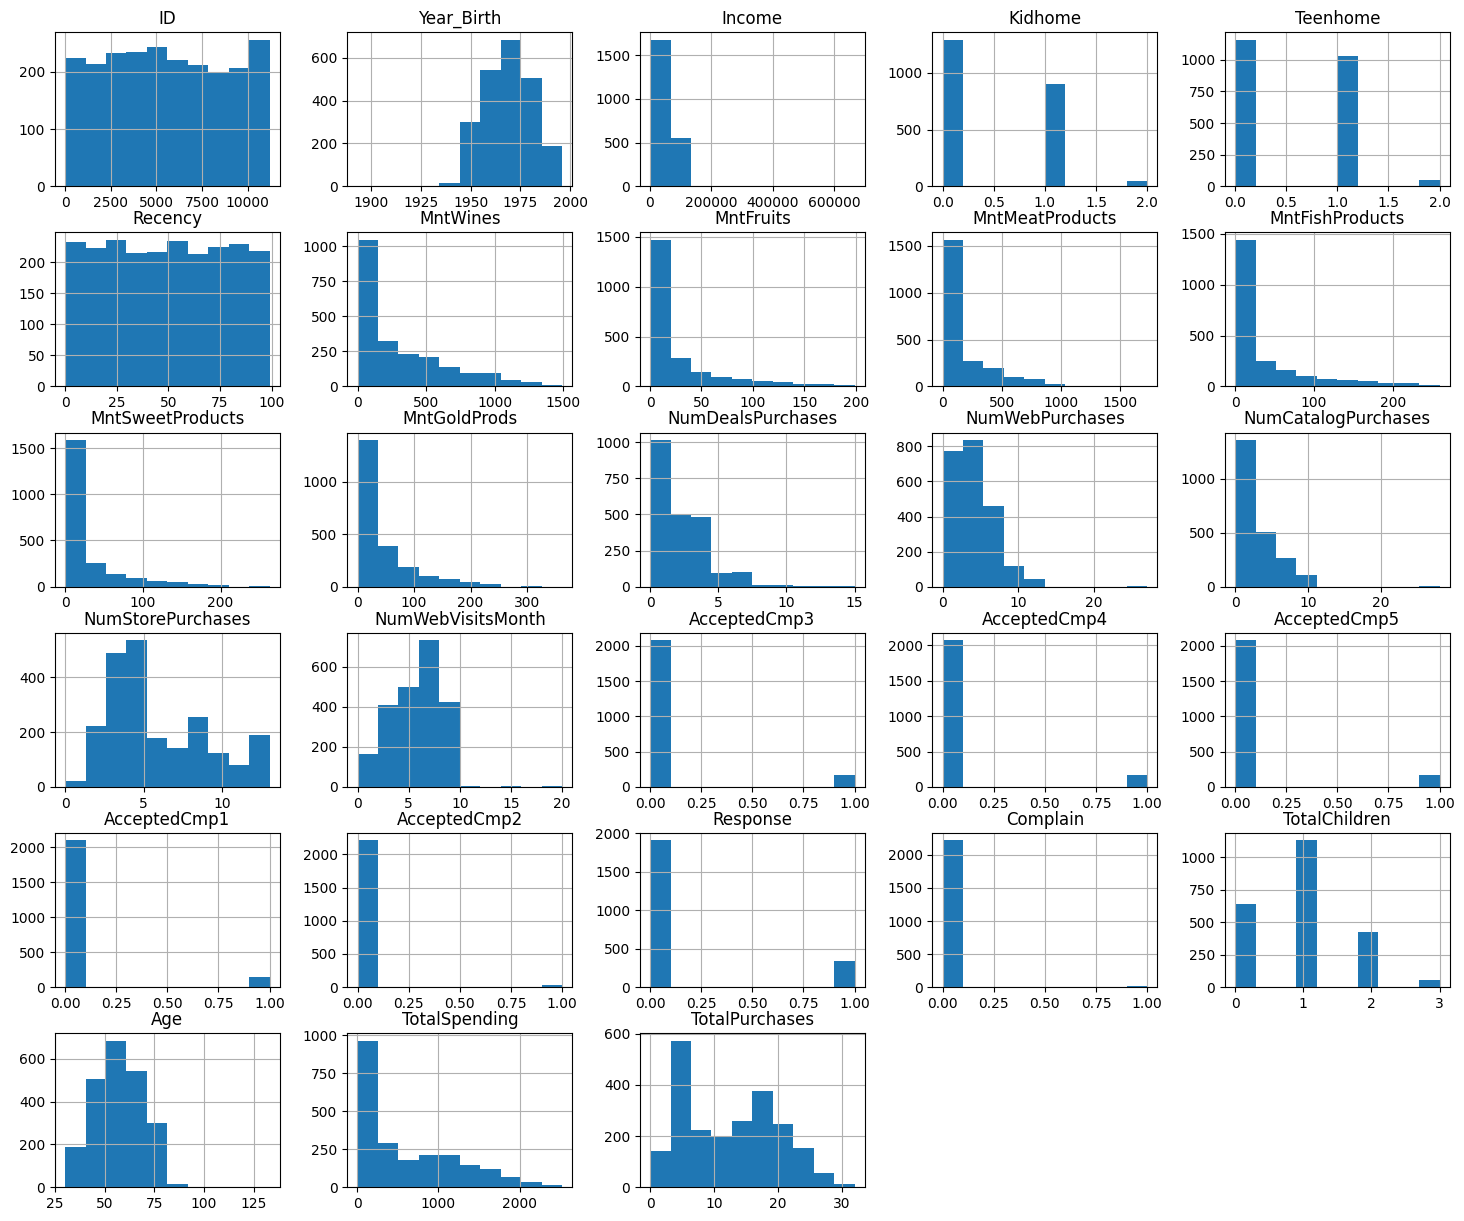

In [37]:
df.hist(figsize=(18,15))
plt.show()

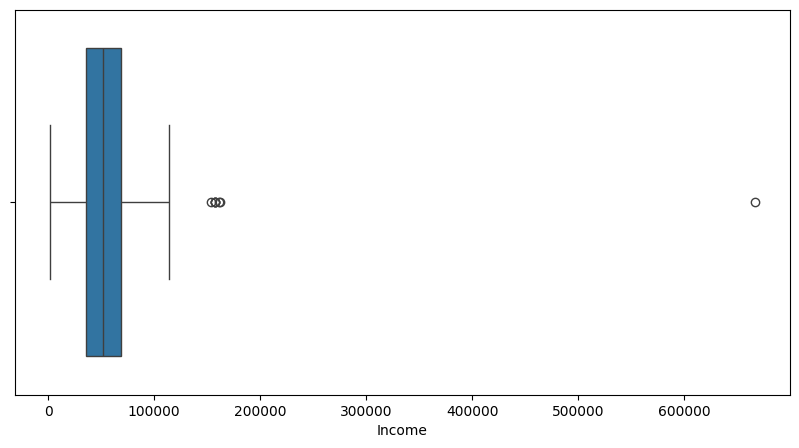

In [38]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Income'])
plt.show()

In [39]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Income'] >= lower) &
        (df['Income'] <= upper)]

In [40]:
education_order = {
    'Basic':1,
    '2n Cycle':2,
    'Graduation':3,
    'Master':4,
    'PhD':5
}

df['Education'] = df['Education'].map(education_order)

In [41]:
df = pd.get_dummies(
    df,
    columns=['Marital_Status']
)

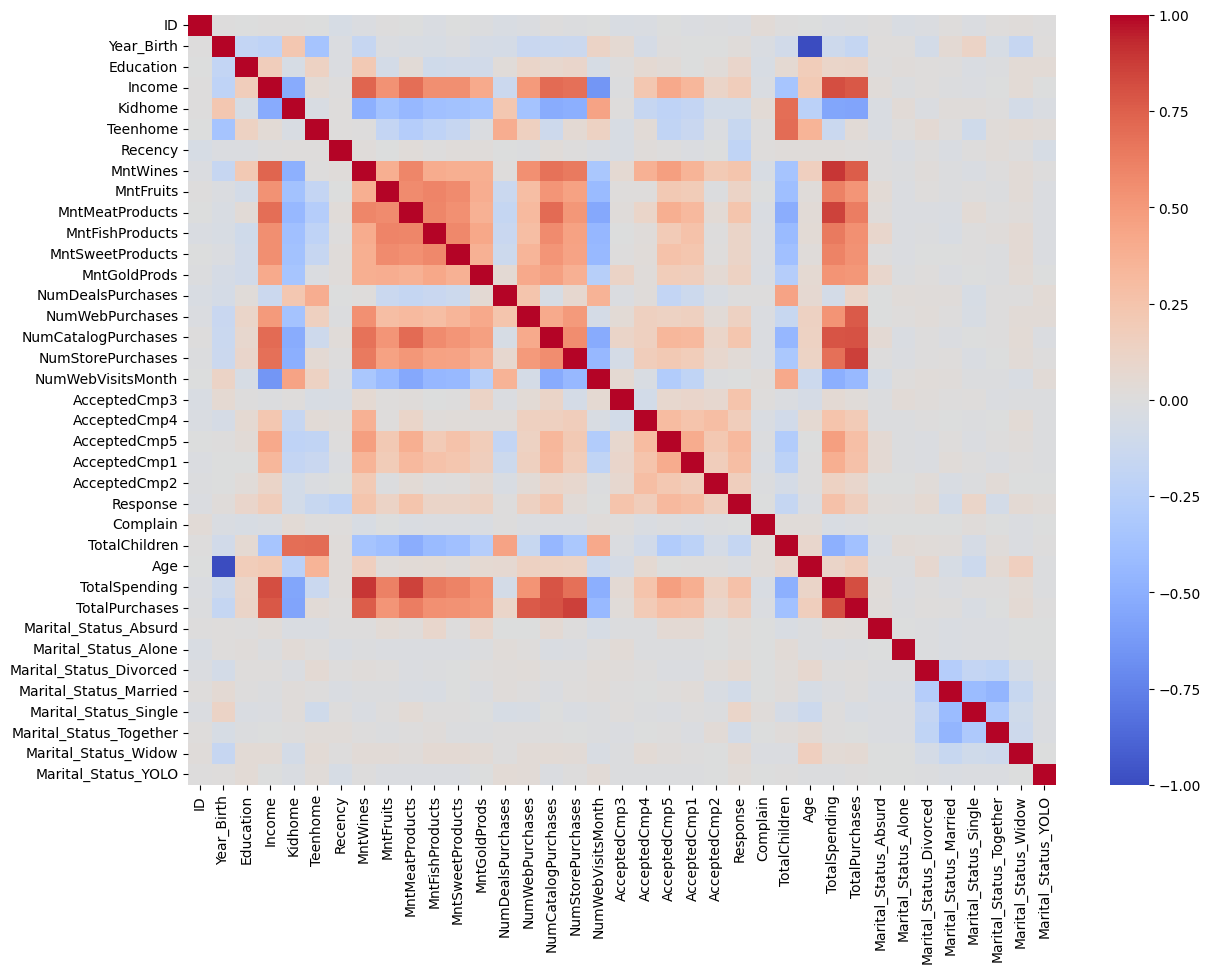

In [42]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()

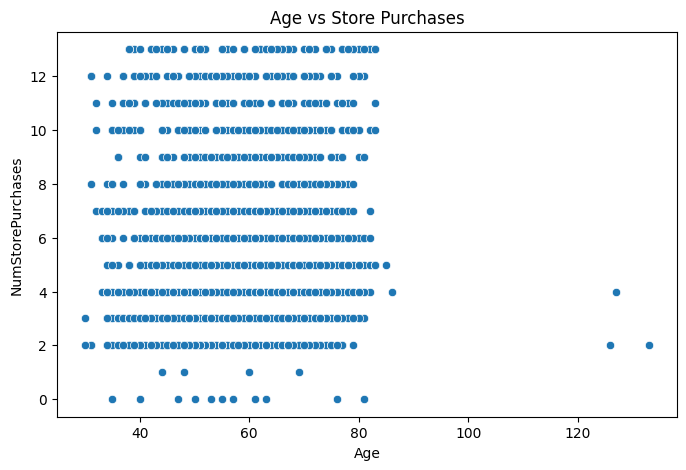

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='NumStorePurchases',
    data=df
)

plt.title('Age vs Store Purchases')

plt.show()

Older customers show a moderate tendency toward store purchases,
suggesting traditional shopping preferences among older age groups.

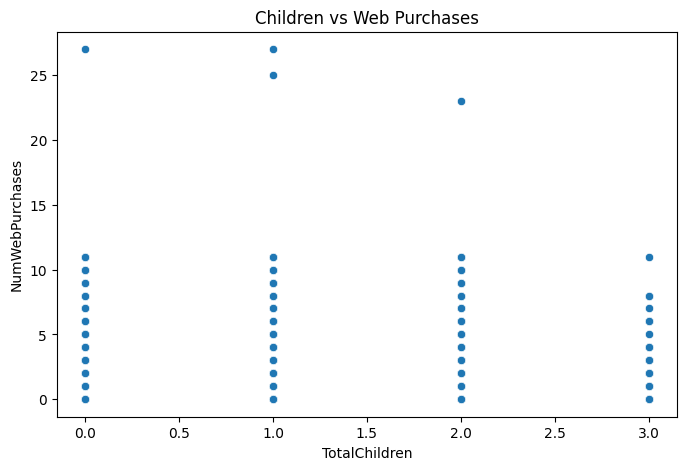

In [44]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TotalChildren',
    y='NumWebPurchases',
    data=df
)

plt.title('Children vs Web Purchases')

plt.show()

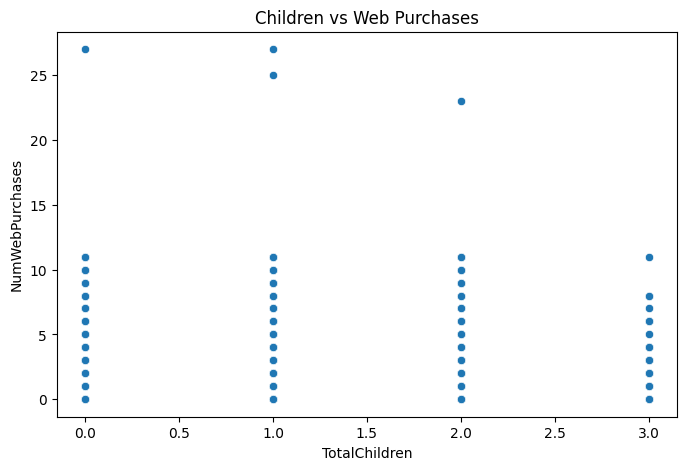

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TotalChildren',
    y='NumWebPurchases',
    data=df
)

plt.title('Children vs Web Purchases')

plt.show()

Customers with more children appear to use online shopping channels more frequently,
possibly due to convenience and time-saving benefits.


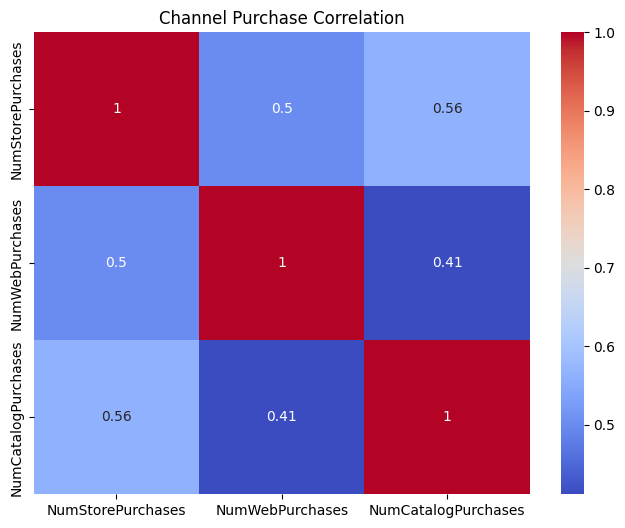

In [46]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        ['NumStorePurchases',
         'NumWebPurchases',
         'NumCatalogPurchases']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Channel Purchase Correlation')

plt.show()

The correlations between channels indicate possible overlap between
shopping methods, suggesting potential cannibalization effects.

In [47]:
df.groupby('Country')['TotalPurchases'].sum().sort_values(ascending=False)

Country
SP     13580
SA      4267
CA      3457
AUS     1952
IND     1712
GER     1530
US      1444
ME        52
Name: TotalPurchases, dtype: int64

The comparison shows whether the United States contributes significantly
higher purchase volumes than other countries.


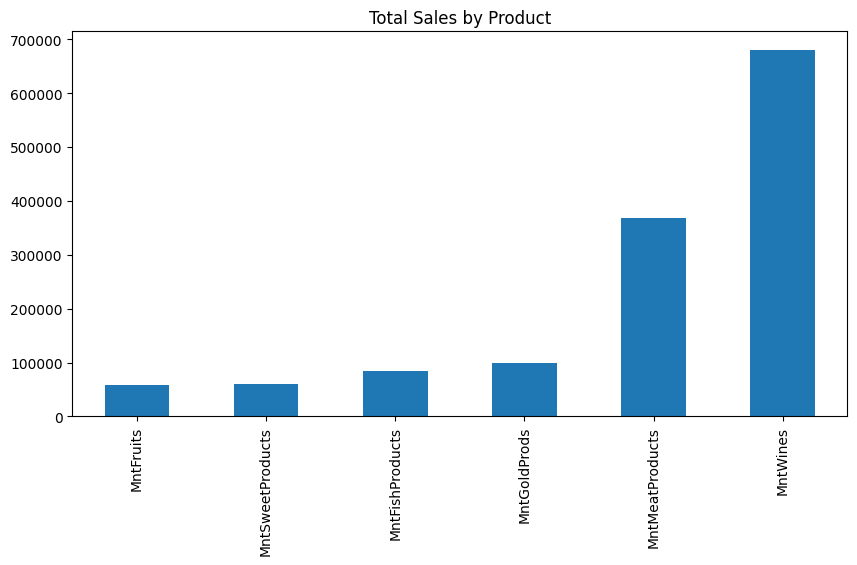

In [48]:
products = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df[products].sum().sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Total Sales by Product')

plt.show()

Wine products generated the highest revenue,
while fruits and sweets contributed comparatively less.

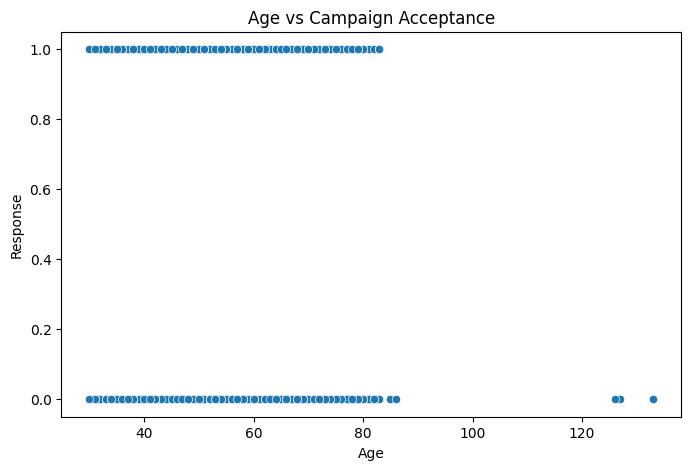

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Response',
    data=df
)

plt.title('Age vs Campaign Acceptance')

plt.show()

In [50]:
df.groupby('Country')['Response'].sum().sort_values(ascending=False)

Country
SP     176
SA      52
CA      38
AUS     23
GER     17
IND     13
US      13
ME       2
Name: Response, dtype: int64

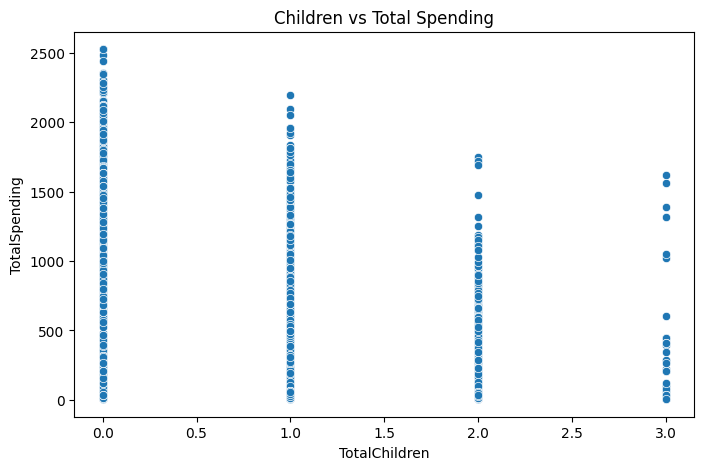

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TotalChildren',
    y='TotalSpending',
    data=df
)

plt.title('Children vs Total Spending')

plt.show()

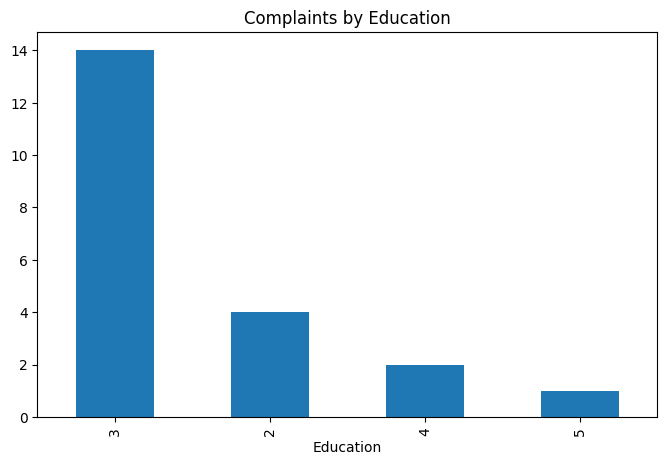

In [52]:
complaints = df[df['Complain'] == 1]

complaints['Education'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Complaints by Education')

plt.show()

# Conclusion

1. Missing income values were successfully handled using grouped mean imputation.

2. Older customers showed a preference for in-store purchases.

3. Customers with children demonstrated higher web purchase activity.

4. Wine products generated the highest sales revenue among all products.

5. Correlation analysis indicated relationships between customer income,
spending behavior, and purchasing channels.

6. Campaign acceptance varied across age groups and countries.

7. The project successfully applied data preprocessing,
visualization, feature engineering, encoding, and exploratory data analysis techniques.